Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

Это задание немного отличается по структуре, тут нет конкретных заданий, вам нужно будет **ЗАПОЛНИТЬ ПРОПУСКИ** и сделать так, чтобы все работало. Ну и, конечно, написать **ВЫВОДЫ**!!!
***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score

# Введение

В этом домашнем задании мы поработаем с алгоритмами **понижения размерности данных**.  
Почему это вообще нужно и важно?

Во-первых, это немного похоже (и правда используется) на **кластеризацию**. В прошлой домашке вы поработали с регрессией и классификацией, а в этой пришло время и для «кластеризации».

***так и кластеризацию мы прежде делали...***

Во-вторых, вообще говоря основная причина, такие алгоритмы помогают выделять значимые фичи в случае, когда **размерность данных (очень) большая**.

_**Пару слов про большую размерность и данные**_

Что вообще такое большая размерность? Это ситуация, когда количество признаков $D$ сравнимо с количеством объектов $n$ или даже превышает его. Например:
* изображение $28 \times 28$ пикселей = **784 признака**;
* текстовые данные после векторизации = **тысячи признаков**;
* генетические данные = **десятки тысяч признаков**.

Заметили, что речи про табличные данные не идет? Это не означает, что такие данные не страдают от «проклятия размерности» (кстати, когда такое может быть?), просто очевидные для человека проблемы не так видны.

_**Проблемы большой размерности:**_

| Проблема | Значение |
|----------|----------|
| **Вычислительная сложность** | Многие алгоритмы масштабируются как $O(D^2)$ или $O(D^3)$ |
| **Проклятие размерности** | В высоких размерностях все точки становятся «одинаково далеко» друг от друга |
| **Переобучение** | Модель запоминает шум вместо закономерностей |
| **Интерпретируемость** | Человеку сложно анализировать пространства с $D > 3$ |

_**Что дают методы снижения размерности:**_

1. **сжатие данных** — хранение и обработка становятся быстрее,
2. **визуализация** — возможность увидеть данные в 2D/3D,
3. **удаление шума** — отбрасываем компоненты с малой дисперсией,
4. **улучшение качества** — иногда классификаторы работают лучше на сниженных данных.

То есть можно выделить _**две основных цели**_ использования таких методов:
* **визуализация** данных для возможности интерпретации человеческим взглядом,
* **выделение фичей** для регрессии и классификации или прямое решение задачи **кластеризации**.

> В этой домашке будет два задания, вы поработаете на обе цели и сравните разные методы.

***
Теперь немного отдельно про каждый алгоритм. Мы не будем говорить про все возможные методы, поговорим про основные.

### PCA (Principal Component Analysis)

Кратенько и на русском [про PCA](https://habr.com/ru/articles/799001/)

Основная идея: найти такое **линейное подпространство меньшей размерности**, в которое можно спроецировать данные с минимальной потерей информации.

Пусть $X \in \mathbb{R}^{n \times D}$ — матрица данных с $n$ объектами и $D$ признаками.
Мы ищем проекцию $Y \in \mathbb{R}^{n \times d}$, где $d < D$, такую что:

$$
Y = XW, \quad W \in \mathbb{R}^{D \times d}
$$

где столбцы матрицы $W$ — ортонормированные векторы (главные компоненты).

PCA **максимизирует дисперсию** спроецированных данных:

$$
\max_{W: W^TW = I} \text{Tr}(W^T \Sigma W)
$$

где $\Sigma = \frac{1}{n}X^TX$ — ковариационная матрица (для центрированных данных).

Решение: столбцы $W$ — **собственные векторы** $\Sigma$, соответствующие 
наибольшим собственным значениям $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_D$.

> Если первые 30 компонент объясняют 85% дисперсии, значит мы сохранили 85% "информации" исходных данных при сжатии в 30 раз.

То есть это некоторый **алгоритм обучения без учителя**!

### t-SNE (t-distributed Stochastic Neighbor Embedding)

Это тоже алгоритм машинного обучения, на русском про него [тут](https://habr.com/ru/articles/267041/)

Основная идея: **нелинейное снижение размерности** с сохранением локальной структуры данных — близкие точки в исходном пространстве остаются близкими.

_**Алгоритм очень простыми словами**_

1. **В исходном пространстве** ($\mathbb{R}^D$):
   - Для каждой пары точек $(i, j)$ вычисляем условную вероятность:
   $$
   p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}
   $$
   - Симметризуем: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

2. **В пространстве низкой размерности** ($\mathbb{R}^d$, обычно $d=2$):
   - Используем t-распределение Стьюдента с 1 степенью свободы:
   $$
   q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l}(1 + ||y_k - y_l||^2)^{-1}}
   $$

3. **Оптимизация**: минимизируем расхождение Кульбака-Лейблера:
   $$
   KL(P||Q) = \sum_{i \neq j} p_{ij} \log\frac{p_{ij}}{q_{ij}}
   $$
   с помощью градиентного спуска.

_**Гиперпараметры:**_

| Параметр | Описание |  |
|----------|----------|------------------|
| `n_components` | Размерность выхода | 2, 3 |
| `perplexity` | Баланс локальной/глобальной структуры | 5–50 |
| `learning_rate` | Шаг градиентного спуска | 10–1000 |
| `n_iter` | Число итераций оптимизации | ≥ 250 |

> t-SNE не сохраняет глобальные расстояния и масштабы кластеров! Интерпретируйте только относительную близость точек.

### UMAP (Uniform Manifold Approximation and Projection)

Про все и [про Umap](https://habr.com/ru/companies/newprolab/articles/350584/) тоже

Основная идея: аппроксимация многообразия данных с **сохранением как локальной, 
так и глобальной** структуры.

1. Предполагается, что данные равномерно распределены на римановом многообразии
2. Строится взвешенный граф соседства в исходном пространстве
3. Оптимизируется расположение точек в низкой размерности для сохранения структуры графа

```python
umap.UMAP(
    n_components=2,      # целевая размерность
    n_neighbors=15,      # размер локального окружения (аналог perplexity)
    min_dist=0.1,        # минимальное расстояние между точками в эмбеддинге
    metric='euclidean',  # метрика расстояния
    random_state=42
)
```

***

Ну чтож, давайте делать! Реализовывать ничего не надо будет, надо будет _применять_ и _интерпретировать_.

# Задание 1: большая и страшная размерность (6 pt)

### Данные

Для этого задания мы с вами возьмем новый для нас вид данных (в предверии следующей темы) — **картиночки**!

Будем использовать классический датасет `MNIST` с изображениями десяти цифр (10 классов). Каждая картинка как и в примере — это $28 \times 28$ пикселей = **784 признака**. 

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist["data"], mnist["target"]

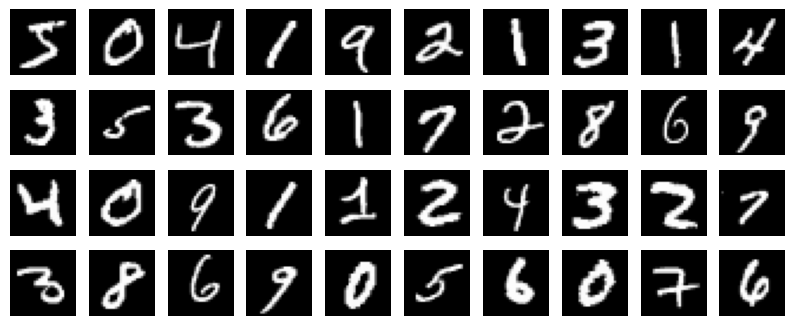

In [3]:
plt.figure(figsize=(10, 4))
for i in range(40):
    plt.subplot(4, 10, i + 1)
    plt.imshow(np.array(X[i]).reshape((28, 28)), cmap='gray')
    plt.axis('off')

Разделим наше все на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(56000, 784)
(14000, 784)


### Применение алгоритмов (3 pt)

Давайте теперь попробуем **понизить размерность в... 15 раз**!

На train выборке постройте **проекцию на 50 главных компонент**. Какую **долю дисперсии** данных они объясняют? Какую долю дисперсии объясняет **каждая компонента по отдельности**?

In [5]:
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)

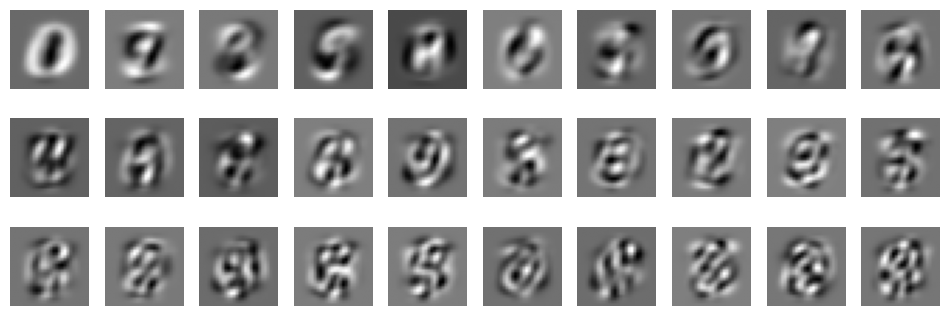

In [6]:
# посмотрите как сожмутся изображения по каждой из компонент

plt.figure(figsize=(12, 4))    
for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.imshow(pca.components_[i].reshape((28, 28)), cmap='gray')
    plt.axis('off')

In [7]:
# ответ на вопрос какую долю дисперсии объясняют компоненты
print(f'Доля объясненной дисперсии: {sum(pca.explained_variance_ratio_)}')

Доля объясненной дисперсии: 0.8254553873544407


In [8]:
# ответ на вопрос какую дисперсию объясняет каждая из компонент
print(pca.explained_variance_ratio_)

[0.09726413 0.07140394 0.06141834 0.05413139 0.04886136 0.04303934
 0.03275354 0.02892666 0.02751649 0.02353269 0.02102951 0.0204529
 0.01712654 0.01700051 0.01583523 0.01492433 0.0131968  0.0127985
 0.0118516  0.01150465 0.01070472 0.01012082 0.0095572  0.00911185
 0.00885558 0.00838818 0.008117   0.00783857 0.00739994 0.00690896
 0.00658036 0.00646972 0.0059983  0.00587726 0.00566512 0.00545142
 0.00504195 0.00488284 0.0048051  0.00468289 0.00454225 0.00444201
 0.00417036 0.00396787 0.00384284 0.00375857 0.00363001 0.00349351
 0.00338934 0.00319241]


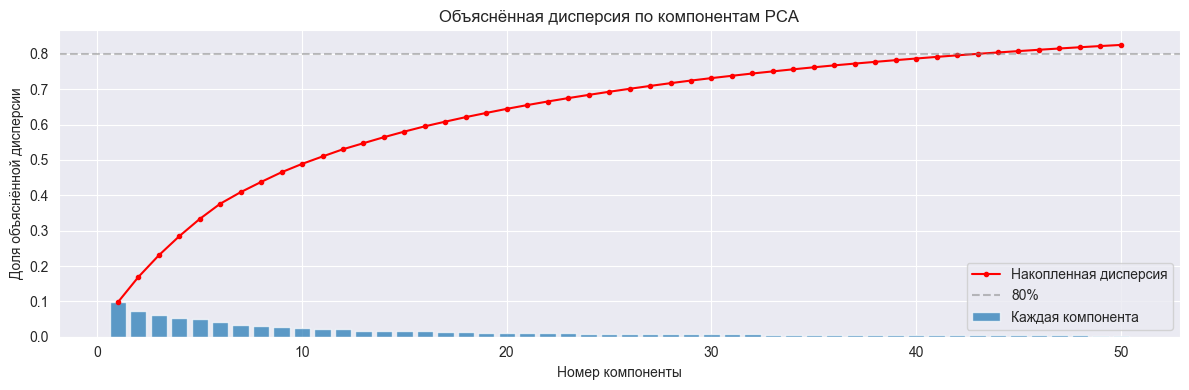

In [9]:
# предыдущий пункт в наглядном виде графика
plt.figure(figsize=(12, 4))
plt.bar(range(1, 51), pca.explained_variance_ratio_, alpha=0.7, label='Каждая компонента')
plt.plot(range(1, 51), np.cumsum(pca.explained_variance_ratio_), color='red', marker='o', markersize=3, label='Накопленная дисперсия')
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='80%')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Объяснённая дисперсия по компонентам PCA')
plt.legend()
plt.tight_layout()
plt.show()

**ВАШ ВЫВОД** про объяснение дисперсии и оптимальную размерность

50 компонент из 784 объясняют ~82.5% дисперсии. По графику накопленная дисперсия растёт без чёткого «локтя». Первые несколько компонент объясняют заметно больше остальных (~10%, 7%, 6%...), но резкого излома нет. Информация в датасете распределена по многим компонентам, порог получится выбирать только исходя из желаемого процента сохранённой дисперсии.

Теперь **визуализируйте главные компоненты**. Легко ли они интерпретируются/разделяют данные?

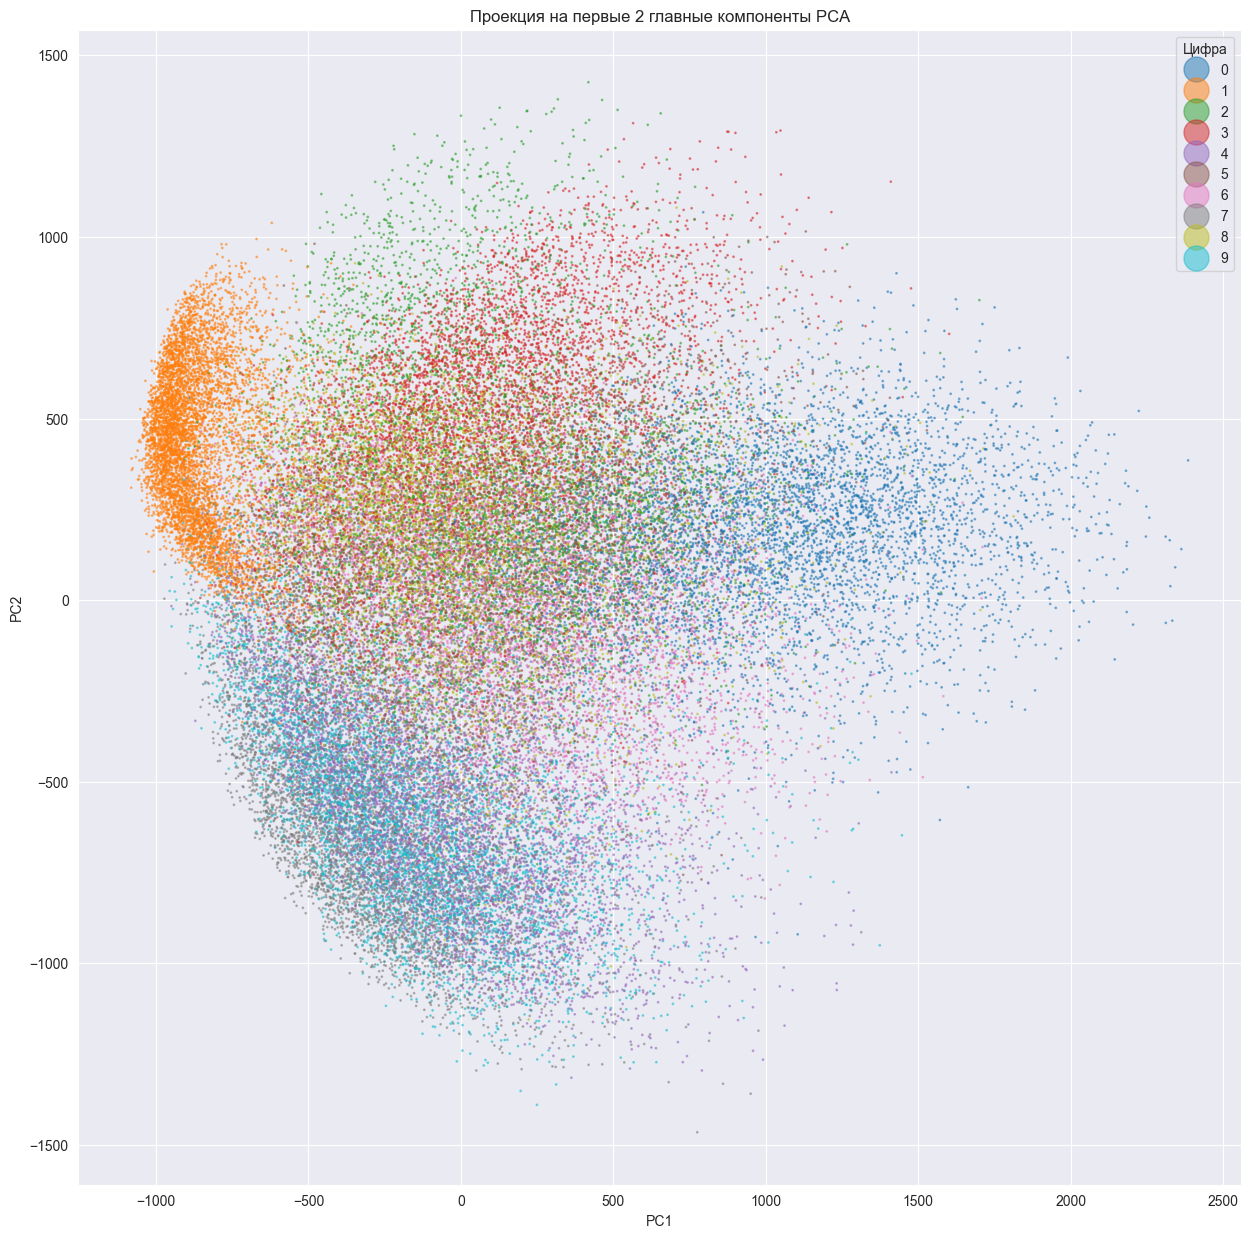

In [10]:
y_numeric_train = y_train.astype(int)
mnist_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

plt.figure(figsize=(15, 15))
scat = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_numeric_train, cmap='tab10', s=1, alpha=0.5)
plt.legend(handles=scat.legend_elements()[0], labels=mnist_labels, title='Цифра', markerscale=3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Проекция на первые 2 главные компоненты PCA')

plt.show()

**ВАШ ВЫВОД** про разделимость

Классы на PCA-проекции плохо разделяются: большинство цифр образуют просто плотное облако в центре. Выделяется только одна группа - оранжевая (1 класс). Остальные 9 классов сильно перекрываются. PCA, в конце концов, не про максимизацию разделимости, так что проблем не вижу.

### Теперь давайте еще визуализируем данные при помощи **t-SNE** и **UMAP**.

Но для начала поймем, на каких данных эти алгоритмы применять. _Что лучше использовать на исходных признаках (значениях пикселей), а что на главных $ компонентах?_

**ВАШ ОТВЕТ:**

Как говорилось в докладе Миши и Влада, t-SNE лучше применять на PCA-сжатых данных, "это ускоряет работу и убирает шум". UMAP эффективнее работает на исходных данных, так как он "лучше сохраняет глобальную структуру и масштабирует на большие датасеты".

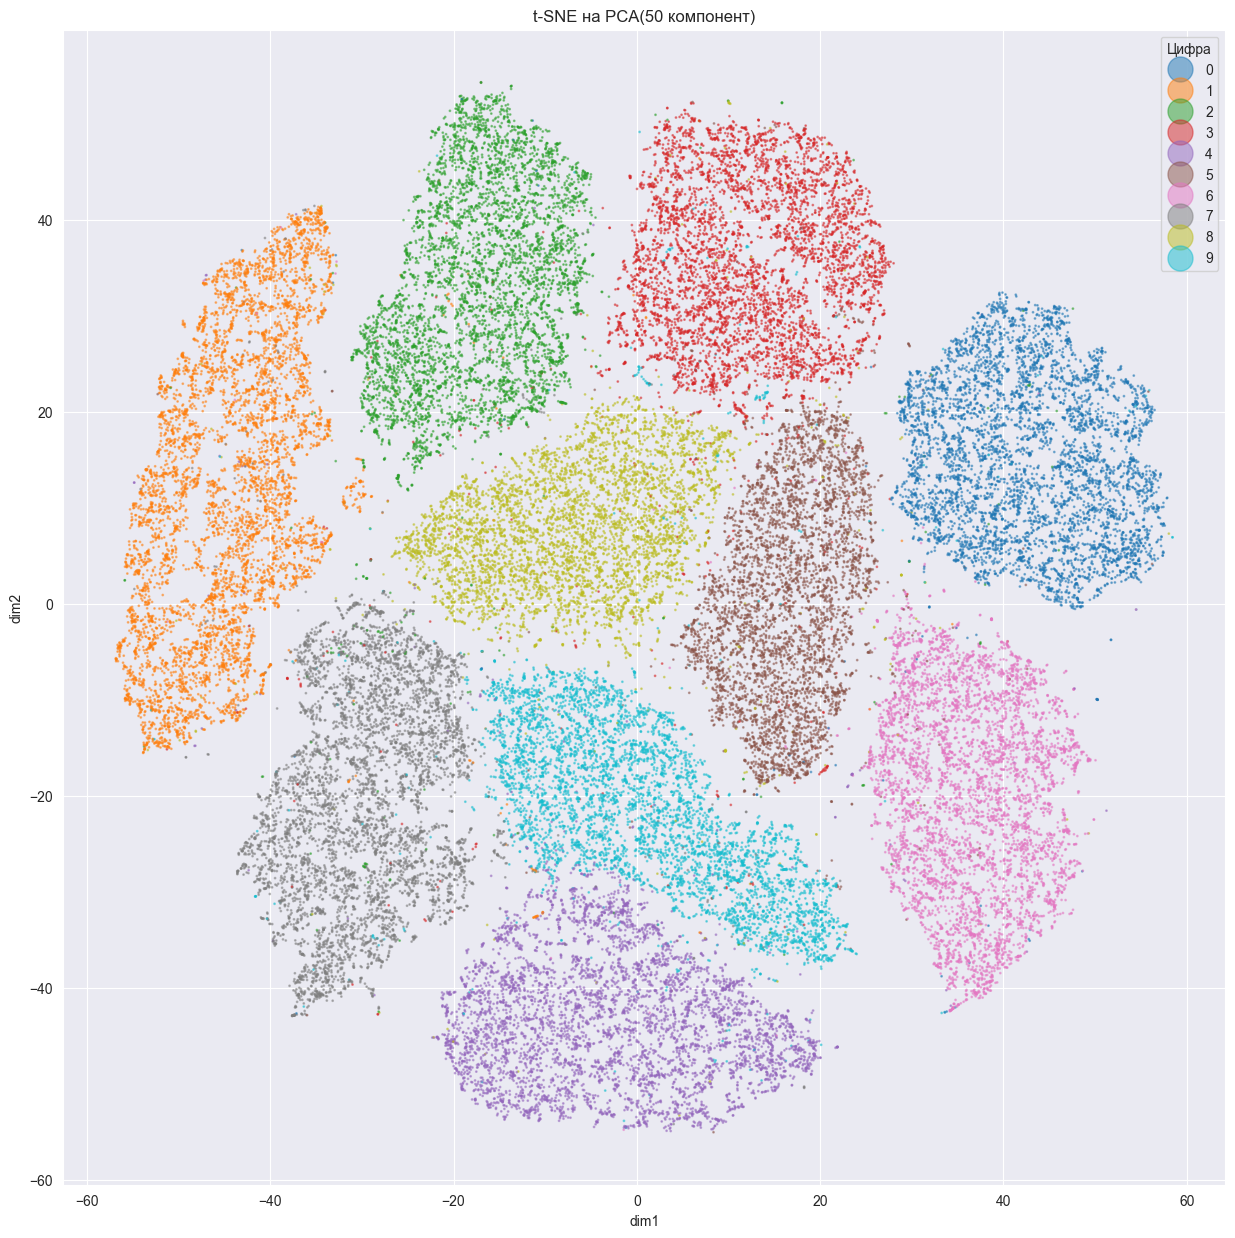

In [11]:
# используем t-SNE для PCA-сжатых данных 
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_train_tsne = tsne.fit_transform(X_train_pca)

plt.figure(figsize=(15, 15))
scat = plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_numeric_train, cmap='tab10', s=1, alpha=0.5)
plt.legend(handles=scat.legend_elements()[0], labels=mnist_labels, title='Цифра', markerscale=3)
plt.xlabel('dim1')
plt.ylabel('dim2')
plt.title('t-SNE на PCA(50 компонент)')

plt.show()

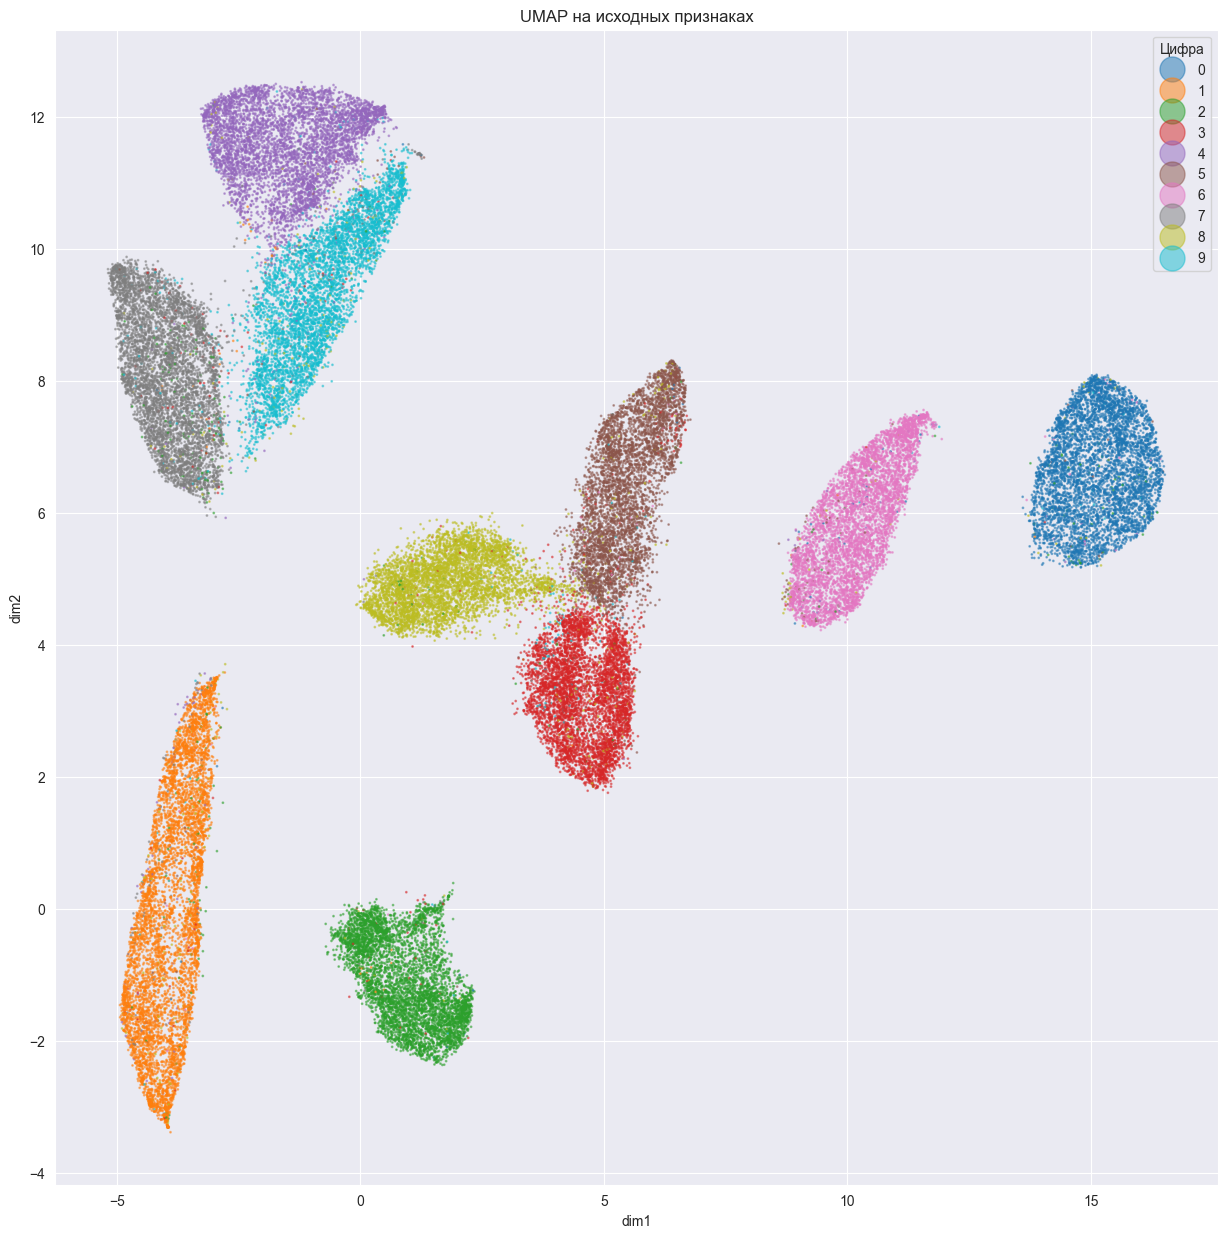

In [12]:
# используем UMAP для исходных признаков

umap_ = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42, n_jobs=1)
X_train_umap = umap_.fit_transform(X_train)

plt.figure(figsize=(15, 15))
scat = plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_numeric_train, cmap='tab10', s=1, alpha=0.5)
plt.legend(handles=scat.legend_elements()[0], labels=mnist_labels, title='Цифра', markerscale=3)
plt.xlabel('dim1')
plt.ylabel('dim2')
plt.title('UMAP на исходных признаках')

plt.show()

**ВАШ ВЫВОД** по применению методов и объяснению, почему оно так получается

t-SNE и UMAP дают принципиально лучшую визуализацию, чем PCA: каждая из 10 цифр образует отдельный плотный кластер с минимальным перекрытием. PCA — линейный метод, он сохраняет дисперсию, а не разделимость, поэтому в 2D-проекции классы сливаются в одно облако.

t-SNE применяется на PCA(50)-данных: сначала PCA убирает шум и снижает размерность до разумного числа, а потом работает t-SNE. UMAP применяется на исходных данных, т.к. он более устойчив к размерности и быстрее работает. Оба метода справляются с задачей визуализации отлично, при этом UMAP лучше сохраняет глобальные расстояния между кластерами (похожие цифры ближе друг к другу).

### Обучение модели (3 pt)

Давайте теперь попробуем использовать полученные ранее результаты для **обучения классификатора**. Будем использовать максимально простой — логистическую регрессию.

Нужно:
1. обучить модель для каждого метода,
2. оценить качество при помощи `accuracy`, `recall` и `f1`.

In [13]:
# сохраним значения для сравнения

metrics = {
    'pca' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    },
    't-sne' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    },
    'umap' : {
        'accuracy' : 0,
        'recall' : 0,
        'f1' : 0
    }
}

y_numeric_train = y_train.astype(int)
y_numeric_test = y_test.astype(int)

In [14]:
# обучаем после pca

model_pca = LogisticRegression(max_iter=1000, random_state=42, solver='saga')
model_pca.fit(X_train_pca, y_numeric_train)

X_test_pca = pca.transform(X_test)

predicted_pca = model_pca.predict(X_test_pca)

metrics['pca']['accuracy'] = accuracy_score(y_numeric_test, predicted_pca)
metrics['pca']['recall'] = recall_score(y_numeric_test, predicted_pca, average='weighted')
metrics['pca']['f1'] = f1_score(y_numeric_test, predicted_pca, average='weighted')

print(f"accuracy = {metrics['pca']['accuracy']}")
print(f"recall = {metrics['pca']['recall']}")
print(f"F1-score = {metrics['pca']['f1']}")

accuracy = 0.9008571428571429
recall = 0.9008571428571429
F1-score = 0.9001197732622156


In [15]:
# обучаем после t-sne
# t-sne не сохраняет данные для изменения, надо заново учить его на тесте

model_tsne = LogisticRegression(max_iter=1000, random_state=42)
model_tsne.fit(X_train_tsne, y_numeric_train)

X_test_pca_for_tsne = pca.transform(X_test)
X_test_tsne = tsne.fit_transform(X_test_pca_for_tsne)

predicted_tsne = model_tsne.predict(X_test_tsne)

metrics['t-sne']['accuracy'] = accuracy_score(y_numeric_test, predicted_tsne)
metrics['t-sne']['recall'] = recall_score(y_numeric_test, predicted_tsne, average='weighted')
metrics['t-sne']['f1'] = f1_score(y_numeric_test, predicted_tsne, average='weighted')

print(f"accuracy = {metrics['t-sne']['accuracy']}")
print(f"recall = {metrics['t-sne']['recall']}")
print(f"F1-score = {metrics['t-sne']['f1']}")

accuracy = 0.707
recall = 0.707
F1-score = 0.6887123832838198


In [16]:
# обучаем после umap

model_umap = LogisticRegression(max_iter=1000, random_state=42)
model_umap.fit(X_train_umap, y_numeric_train)

X_test_umap = umap_.transform(X_test)

predicted_umap = model_umap.predict(X_test_umap)

metrics['umap']['accuracy'] = accuracy_score(y_numeric_test, predicted_umap)
metrics['umap']['recall'] = recall_score(y_numeric_test, predicted_umap, average='weighted')
metrics['umap']['f1'] = f1_score(y_numeric_test, predicted_umap, average='weighted')

print(f"accuracy = {metrics['umap']['accuracy']}")
print(f"recall = {metrics['umap']['recall']}")
print(f"F1-score = {metrics['umap']['f1']}")

accuracy = 0.9397142857142857
recall = 0.9397142857142857
F1-score = 0.9395596781119149


**ВАШИ ВЫВОДЫ** про обучение и сам подход к изменению признаков

UMAP даёт лучшее качество, PCA - немного хуже, но сопоставимо хорошее. t-SNE - заметно хуже. Думаю, это связано с тем, что он не учит функцию, а просто итеративно оптимизирует позиции конкретных точек, Поэтому в целом чего-то похожего на инференс там быть не может, как я понимаю, в отличие от PCA и UMAP, которые находят преобразование пространства.  

# Задание 2: понижение для фичей (4 pt)

В этом задании снова поработаем с классификацией, но уже с **табличными данными**.

Будем использовать простельний датасет для классивикации вин (я не виновата, что хорошие датасеты такие..., что нашла, то нашла).

### Данные (1 pt)

In [17]:
data = load_wine()
X, y = data['data'], data['target']
X.shape

(178, 13)

Датасет маленький, видно, что от проклятия размерности мы тут не страдаем.

In [18]:
print(data['DESCR'])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

Делим на test и train, **поделим практически поровну**, иммитируя маленькое количество данных, и чтобы было, на чем сверяться.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(106, 13)
(72, 13)


Сначала сделаем **стандартизацию данных**. Объясните, почему она тут нужна.

_Посмотрите на данные (оставьте только 2-3 нужных графика!)_

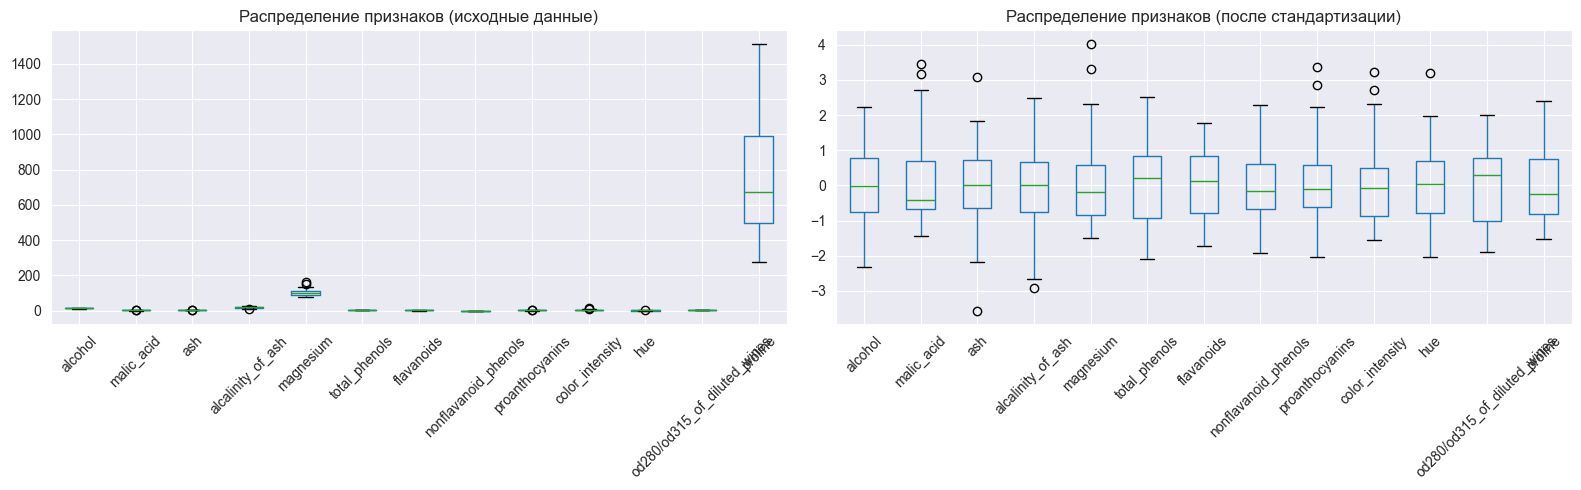

In [20]:
# тут код для ответа на вопрос про зачем нужна

df = pd.DataFrame(X_train, columns=data['feature_names'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df.boxplot(ax=axes[0])
axes[0].set_title('Распределение признаков (исходные данные)')
axes[0].tick_params(axis='x', rotation=45)

df_std = (df - df.mean()) / df.std()
df_std.boxplot(ax=axes[1])
axes[1].set_title('Распределение признаков (после стандартизации)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, зачем стандартизировать

Признаки датасета wine имеют очень разные масштабы. PCA находит направления максимальной дисперсии, поэтому без стандартизации он возьмёт в первые компоненты признаки с бОльшими числовыми отличиями, а не с реальной информативностью. После стандартизации будет норм, признаки будут вносить один вклад.

In [21]:
# стандартизируем данные

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Понижение размерности (1 pt)

Теперь давайте визуализируем **проекцию** выборки на первые **две главные компоненты**.

_Как мы это делаем? Разделимы ли классы линейно?_

In [22]:
# что-то применяем

pca_wine = PCA(n_components=2)
X_train_pca_wine = pca_wine.fit_transform(X_train)
X_test_pca_wine = pca_wine.transform(X_test)

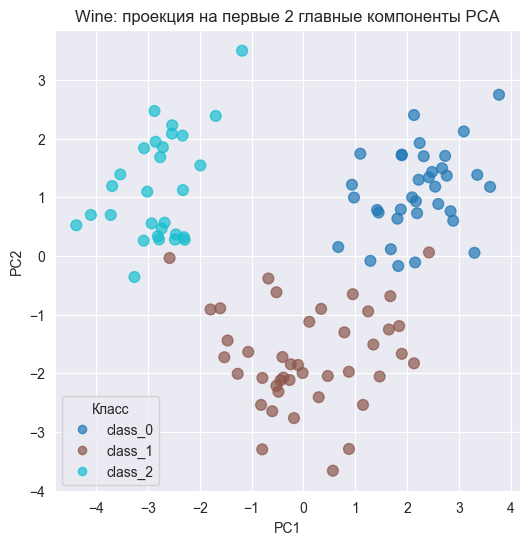

In [23]:
# визуализируем

wine_labels = ['class_0', 'class_1', 'class_2']

plt.figure(figsize=(6, 6))
scat = plt.scatter(X_train_pca_wine[:, 0], X_train_pca_wine[:, 1], c=y_train, cmap='tab10', s=60, alpha=0.7)
plt.legend(handles=scat.legend_elements()[0], labels=wine_labels, title='Класс', markerscale=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Wine: проекция на первые 2 главные компоненты PCA')

plt.show()

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, как делаем и про разделимость

Применяем PCA с 2 компонентами к стандартизированным данным. На графике три класса хорошо разделяются уже в 2D. Лёгкое перекрытие есть между классами 0 и 2, но в целом линейная разделимость присутствует. 

### Обучение модели (2 pt)

Просто обучать уже умеем, тут сделаем чуть более интересную вещь.

Постройте **график зависимоти качества модели** (все так же логистическая регрессия) **от числа компонент**. _Есть какие-то зависимости?_

In [24]:
# учим и запоминаем

model = LogisticRegression(max_iter=1000)
f1 = []
for i in range(1, 14):

    pca_i = PCA(n_components=i)
    X_train_i = pca_i.fit_transform(X_train)
    X_test_i = pca_i.transform(X_test)

    model.fit(X_train_i, y_train)
    y_pred = model.predict(X_test_i)

    f1.append(f1_score(y_test, y_pred, average='weighted'))

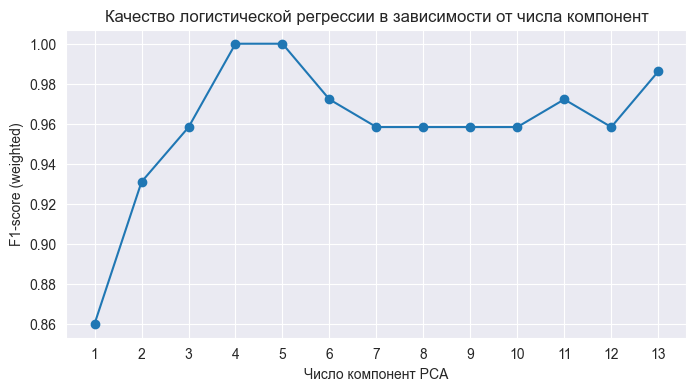

In [25]:
# визуализируем

plt.figure(figsize=(8, 4))
plt.plot(range(1, 14), f1, marker='o')
plt.xlabel('Число компонент PCA')
plt.ylabel('F1-score (weighted)')
plt.title('Качество логистической регрессии в зависимости от числа компонент')
plt.xticks(range(1, 14))
plt.grid(True)

plt.show()

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про зависимости

F1 резко растёт с 1 до 4 компонент (0.86 до 1.00) и достигает максимума уже на 4–5 компонентах. После этого качество слегка падает и колеблется, не улучшаясь при добавлении новых компонент. Это значит, что первые 4–5 главных компонент уже захватывают всю значимую информацию для разделения классов вина. Добавление остальных компонент привносит лишь шум.

***
Давайте теперь воспользуемся знаниями из прошлого дз и обучим `Lasso` регрессию (с L1 регуляризацией), чтобы **выделить важные признаки**. Кстати сделаем мы это немного по-другому.

_В чем отличие такого подхода от pca?_

In [26]:
lasso = LogisticRegression(solver='saga', l1_ratio=1, max_iter=1000)
lasso.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Но ведь регрессия может давать бинарный ответ «да/нет», как быть с тем, что **у нас 3 класса**?

In [27]:
# это поможет понять ответ
lasso.coef_

array([[ 0.        ,  0.        ,  0.        , -0.13149361,  0.        ,
         0.        ,  0.29940351,  0.        ,  0.        ,  0.        ,
         0.        ,  0.5370742 ,  1.80679309],
       [-1.55693758, -0.11525375, -0.7443429 ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.11132825, -1.37553138,
         0.16826789,  0.        , -0.57145757],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -1.9249901 ,  0.        , -0.09868962,  0.        ,
        -1.1242606 , -0.11158507,  0.        ]])

**ВАШ ТЕКСТОВЫЙ ОТВЕТ** на вопрос про то, как же быть с многоклассовой классификацией

LogisticRegression использует стратегию один против всех, т.е. обучается по отдельному классификатору для каждого класса. Каждый из них выдаёт
вероятность принадлежности к своему классу, и финальным ответом будет класс с наибольшей вероятностью. Поэтому lasso.coef_ имеет форму (3, 13), т.е. по одному
набору коэффициентов на каждый классификатор.


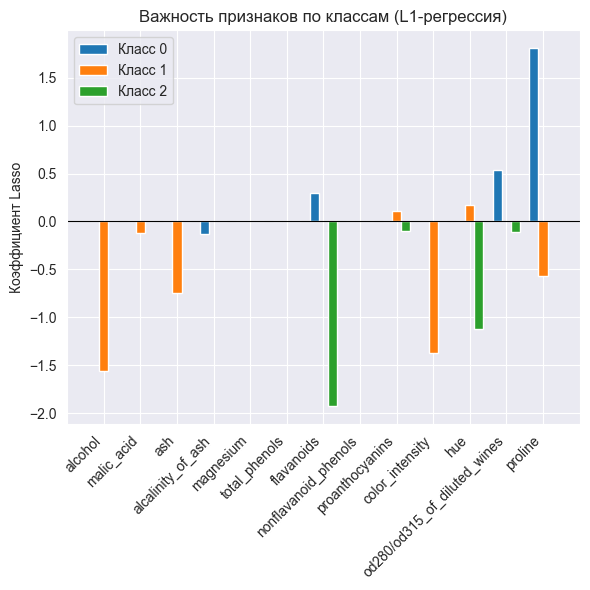

In [28]:
# визуализируем важность всех фич (коэффициенты) для каждого класса

feature_names = data['feature_names']
x = np.arange(len(feature_names))
width = 0.25

plt.figure(figsize=(6, 6))
plt.bar(x - width, lasso.coef_[0], width, label='Класс 0')
plt.bar(x,         lasso.coef_[1], width, label='Класс 1')
plt.bar(x + width, lasso.coef_[2], width, label='Класс 2')
plt.xticks(x, feature_names, rotation=45, ha='right')
plt.ylabel('Коэффициент Lasso')
plt.title('Важность признаков по классам (L1-регрессия)')
plt.axhline(0, color='black', linewidth=0.8)

plt.legend()
plt.tight_layout()
plt.show()

**ВАШ ВЫВОД И ТЕКСТОВЫЙ ОТВЕТ** об отличии от pca

Lasso обнуляет коэффициенты незначимых признаков и оставляет только информативные в оригинальном пространстве. По графику видно, что большинство признаков равны нулю: 
- для класса 0 ключевыми оказались proline и od280/od315
- для класса 1 - alcohol и color_intensity
- для класса 2: flavanoids и hue 

Признаки magnesium, total_phenols, nonflavanoid_phenols обнулились для всех классов, значит они не информативны.

PCA, в отличие от Lasso, создаёт новые оси как линейные комбинации всех 13 признаков, теряя интерпретируемость. Lasso сохраняет исходные признаки, можно легко сказать "вино класса 0 узнаётся по высокому признаку proline".

**ИТОГОВЫЙ ВОПРОС**

Так в итоге что и когда лучше применять, как это использовать и интерпретировать?

**ВАШ ИТОГОВЫЙ ОТВЕТ**

- **PCA** - универсально: линейный, относительно быстрый, детерминированный. Подходит для предобработки перед классификацией, визуализации, удаления шума. Интерпретировать компоненты сложно, т.к. это просто комбинации признаков.
- **t-SNE** - только для визуализации: нелинейный, очень хорошо разделяет кластеры. Нет transform(), значит нельзя применить к новым данным, значит непригоден для классификации. Медленный на больших данных.
- **UMAP** - крут-фрут: быстрее t-SNE, поддерживает transform(), годится и для визуализации, и как признаковое преобразование.
- **Lasso/L1** - когда нужна интерпретируемость: выбирает подмножество исходных признаков, обнуляя незначимые. Позволяет понять, что физически отличает классы друг от друга. Тоже кажется замечательным вариантом, я бы использовал два последних вместе.

***
Ура, все  
P.S. веселое настроение было пока делала

*кайф, рад*